from google.colab import drive
drive.mount("/content/MyDrive")

##Librairies

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
import hashlib
from tqdm.notebook import tqdm
import os
warnings.filterwarnings('ignore')
import psutil
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from transformers import RobertaTokenizer,AutoTokenizer,AutoConfig,BertForPreTraining,AutoModel,BertModel
import torch
import torch.nn as nn
from torch.utils.data import Dataset,DataLoader,TensorDataset
import torch.nn.functional as F
from transformers import get_linear_schedule_with_warmup
from collections import defaultdict
from sklearn.model_selection import train_test_split
import random
from torch.optim import AdamW
import time

In [2]:
def class_balanced_downsample(df, target_col, keep_frac=0.5, random_state=42, min_samples=20):
    """
    Downsamples the top n/2 most populated classes based on keep_frac.
    The bottom n/2 least populated classes are kept untouched.
    
    At keep_frac=1.0, nothing is dropped.
    At keep_frac=0.0, top i classes are reduced to size of the (i+1)th class,
    but never below min_samples.

    Parameters:
    - df: pd.DataFrame
    - target_col: str
    - keep_frac: float ∈ [0, 1], how much of each top-class population to retain
    - random_state: int
    - min_samples: int, minimum samples to keep per downsampled class

    Returns:
    - pd.DataFrame with class-balanced downsampling
    """
    import pandas as pd
    
    assert 0.0 <= keep_frac <= 1.0, "keep_frac must be between 0 and 1."

    # Get class sizes in descending order
    class_counts = df[target_col].value_counts()
    sorted_classes = class_counts.index.tolist()
    num_classes = len(sorted_classes)
    cutoff = 10  # Number of most populated classes to downsample

    # Class used as downsampling baseline
    base_class = sorted_classes[cutoff]
    base_count = class_counts[base_class]

    sampled_dfs = []

    for i, cls in enumerate(sorted_classes):
        class_df = df[df[target_col] == cls]
        count = len(class_df)

        if i < cutoff:
            # Compute target count between original and base_count
            target_count = int(keep_frac * count + (1 - keep_frac) * base_count)
            target_count = min(target_count, count)
            # Enforce minimum samples per class
            if target_count < min_samples:
                target_count = min_samples if min_samples <= count else count
            class_df = class_df.sample(n=target_count, random_state=random_state)
        
        # Lower half of classes: untouched
        sampled_dfs.append(class_df)

    return pd.concat(sampled_dfs).reset_index(drop=True)

In [3]:
keep_frac = 0.02

In [4]:
import os
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"

In [5]:
def memory_check():
  return round(psutil.virtual_memory().used/1024**3,3)

os.chdir('/content/MyDrive/MyDrive/Colab Notebooks/securityBERT')

##PPFLE Algorithm

In [8]:
def PPFLE(M, columns):
  # print(columns)
  # return 0
  DL = []
  for i,v in tqdm(M.iterrows(),desc="Processing...",total=len(M)):
    L = []
    for j in columns:
      L.append(str(v.get(j)))
    DL.append(" ".join(L))
  return DL


In [9]:
# features_to_remove = ['frame.time','ip.src_host', 'ip.dst_host','arp.dst.proto_ipv4','tcp.payload']
# print(data.shape)
# data = data.drop(columns=features_to_remove,axis=0)
# data.shape

In [10]:
data = pd.read_parquet("./data/cic-collection.parquet")
data.head(5)

,Flow Duration,Total Fwd Packets,Total Backward Packets,Fwd Packets Length Total,Bwd Packets Length Total,Fwd Packet Length Max,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,Bwd Packet Length Mean,...,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label,ClassLabel
0,4,2,0,12.0,0.0,6.0,6.00000,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Benign,Benign
1,1,2,0,12.0,0.0,6.0,6.00000,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Benign,Benign
2,3,2,0,12.0,0.0,6.0,6.00000,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Benign,Benign
3,1,2,0,12.0,0.0,6.0,6.00000,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Benign,Benign
4,609,7,4,484.0,414.0,233.0,69.14286,111.967896,207.0,103.5,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Benign,Benign


In [11]:
data = data.drop(columns={"ClassLabel"})

In [12]:
label_col = "Label"  # or the actual name of your attack type column
encoded_data_file_name = './saved_data/raw_data_CICIDS2017'
tokenizer_file_name = './tokenizer_CICIDS2017_raw'

if (keep_frac > 0) and (keep_frac < 1.0):
    print(f"Data shape before reduction: {data.shape}")
    data = class_balanced_downsample(data, label_col, keep_frac=keep_frac)
    print(f"Data shape after reduction: {data.shape}")
    encoded_data_file_name += f'_{keep_frac}samples'
    tokenizer_file_name += f'_{keep_frac}samples'

Data shape before reduction: (9167581, 58)
Data shape after reduction: (894198, 58)


In [13]:
data[label_col].value_counts()

Label
Benign                  195001
DDoS-LOIC-HTTP           62784
DoS-Hulk                 57652
DDoS-HOIC                55254
Botnet                   54196
DDoS                     53838
DDoS-NTP                 53704
DDoS-TFTP                53254
Bruteforce-SSH           53222
Infiltration             53174
DoS-Goldeneye            52324
DDoS-Syn                 47757
DDoS-UDP                 28863
DoS-Slowloris            15243
DDoS-MSSQL               11784
DDoS-UDPLag               8452
Bruteforce-FTP            5984
DoS-Slowhttptest          5271
DDoS-Ddossim              5115
DDoS-DNS                  3668
DoS-Slowread              2786
Portscan                  2255
DDoS-LDAP                 2092
Webattack-bruteforce      2020
DDoS-SNMP                 2017
DDoS-Slowloris            1858
DoS-Slowheaders           1649
Webattack-XSS              876
DoS-Rudy                   699
DDoS-NetBIOS               675
DoS-Slowbody               621
Webattack-SQLi              99
Do

In [14]:
columns_object = data.select_dtypes(include=['object']).columns
columns_object = list(columns_object[:-1])

In [15]:
for column in tqdm(columns_object):
  data[column] = data[column].astype(str)


0it [00:00, ?it/s]

In [16]:
data.sample(5)

,Flow Duration,Total Fwd Packets,Total Backward Packets,Fwd Packets Length Total,Bwd Packets Length Total,Fwd Packet Length Max,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,Bwd Packet Length Mean,...,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
594531,386715,22,22,2008.0,2665.0,640.0,91.272728,138.182144,976.0,121.13636,...,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Bruteforce-SSH
239466,977145,3,4,20.0,964.0,20.0,6.666667,11.547006,964.0,241.00000,...,20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,DDoS-LOIC-HTTP
578436,3009428,4,0,2064.0,0.0,516.0,516.000000,0.000000,0.0,0.00000,...,20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,DDoS-TFTP
131080,6767827,4,4,97.0,231.0,97.0,24.250000,48.500000,231.0,57.75000,...,20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Benign
219875,35939499,2,0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.00000,...,20,0.0,0.0,0.0,0.0,35900000.0,0.0,35900000.0,35900000.0,DDoS-LOIC-HTTP


In [17]:
temp = PPFLE(data, list(data.columns[:-1]))

Processing...:   0%|          | 0/894198 [00:00<?, ?it/s]

In [18]:
input_columns = list(data.columns[:-1])
tmp_tokens = temp[0].split()  # splits on any whitespace by default
print("Number of tokens:", len(tmp_tokens))

print("Number of columns", len(input_columns))

Number of tokens: 57
Number of columns 57


In [19]:
for idx, col in enumerate(data.columns):
    print(f"Index {idx}: Column '{col}'")
    print()  # Add empty line for spacing

Index 0: Column 'Flow Duration'

Index 1: Column 'Total Fwd Packets'

Index 2: Column 'Total Backward Packets'

Index 3: Column 'Fwd Packets Length Total'

Index 4: Column 'Bwd Packets Length Total'

Index 5: Column 'Fwd Packet Length Max'

Index 6: Column 'Fwd Packet Length Mean'

Index 7: Column 'Fwd Packet Length Std'

Index 8: Column 'Bwd Packet Length Max'

Index 9: Column 'Bwd Packet Length Mean'

Index 10: Column 'Bwd Packet Length Std'

Index 11: Column 'Flow Bytes/s'

Index 12: Column 'Flow Packets/s'

Index 13: Column 'Flow IAT Mean'

Index 14: Column 'Flow IAT Std'

Index 15: Column 'Flow IAT Max'

Index 16: Column 'Flow IAT Min'

Index 17: Column 'Fwd IAT Total'

Index 18: Column 'Fwd IAT Mean'

Index 19: Column 'Fwd IAT Std'

Index 20: Column 'Fwd IAT Max'

Index 21: Column 'Fwd IAT Min'

Index 22: Column 'Bwd IAT Total'

Index 23: Column 'Bwd IAT Mean'

Index 24: Column 'Bwd IAT Std'

Index 25: Column 'Bwd IAT Max'

Index 26: Column 'Bwd IAT Min'

Index 27: Column 'Fwd PS

-Index 1: Column 'ip.src_host'

-Index 2: Column 'ip.dst_host'

-Index 27: Column 'tcp.dstport'

-Index 32: Column 'tcp.payload'

-Index 34: Column 'tcp.srcport'

-Index 35: Column 'udp.port'

-Index 54: Column 'mqtt.protoname'

In [20]:
data['raw_input'] = temp
del temp

In [21]:
data = data[['raw_input',label_col]]

In [22]:
data.to_pickle(f'{encoded_data_file_name}.pck')

##Load saved data

In [23]:
data = pd.read_pickle(f'{encoded_data_file_name}.pck')

In [24]:
le = LabelEncoder()
data['target'] = le.fit_transform(data[label_col])

In [25]:
data.sample(3)

,raw_input,Label,target
49752,86051603 2 0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0...,Benign,0
468232,71960163 9 4 62.0 11601.0 20.0 6.8888888359069...,DDoS,4
510646,8338 200 0 88000.0 0.0 440.0 440.0 0.0 0.0 0.0...,DDoS-NTP,11


In [26]:
data['raw_input'][0]

'5037902 8 6 1373.0 911.0 532.0 171.625 236.7554168701172 414.0 151.8333282470703 175.43136596679688 453.3633247 2.778934564 387530.9375 1083586.25 3985682.0 52.0 1052220.0 150317.140625 99794.59375 249526.0 10465.0 4986581.0 997316.1875 1786630.875 4182690.0 927.0 0 172 132 1.5879626274108887 1.1909719705581665 532.0 152.26666259765625 202.20867919921875 40888.3515625 0 0 163.14285278320312 171.625 151.8333282470703 8 1373 6 911 8192 118 7 20 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0'

In [27]:
sorted(data['target'].unique())

[0,
 1,
 2,
 3,
 4,
 5,
 6,
 7,
 8,
 9,
 10,
 11,
 12,
 13,
 14,
 15,
 16,
 17,
 18,
 19,
 20,
 21,
 22,
 23,
 24,
 25,
 26,
 27,
 28,
 29,
 30,
 31,
 32]

In [28]:
# data.to_pickle('./encoded_data.pickle')

In [29]:
memory_check()

23.515

In [30]:
with open(f'{encoded_data_file_name}.txt',"w") as f:
  for value in tqdm(data['raw_input']):
    f.write(str(value)+'\n')


  0%|          | 0/894198 [00:00<?, ?it/s]

##Data splitting

In [31]:
train_set = data.sample(frac=0.7,random_state=42).reset_index(drop=True)

remaining = data.drop(train_set.index).reset_index(drop=True)

test_set = remaining.sample(frac=0.5,random_state=42).reset_index(drop=True)

val_set = remaining.drop(test_set.index).reset_index(drop=True)

print(train_set.shape,val_set.shape,test_set.shape)

(625939, 3) (134129, 3) (134130, 3)


In [32]:
train_ratio = 0.7
val_ratio = 0.15
test_ratio = 0.15

In [33]:
train_set, test_set = train_test_split(data, test_size=test_ratio,stratify=data.iloc[:,-1], random_state=42)
train_set, val_set = train_test_split(train_set, test_size=val_ratio/(val_ratio+train_ratio),stratify=train_set.iloc[:,-1], random_state=42)

In [34]:
train_set.shape,val_set.shape,test_set.shape

((625938, 3), (134130, 3), (134130, 3))

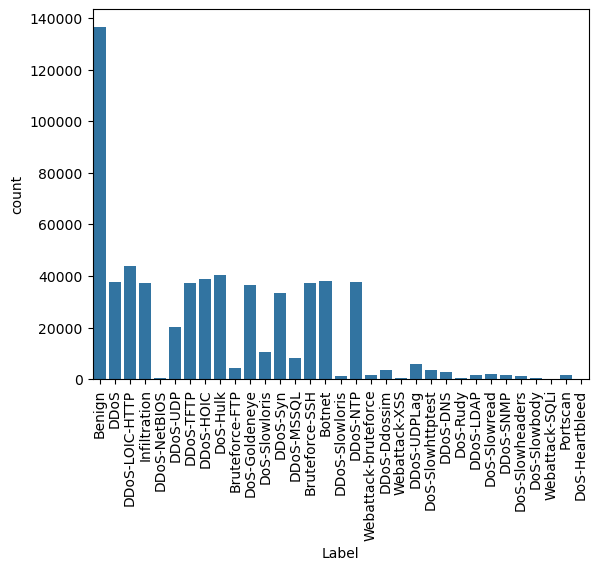

In [35]:
sns.countplot(train_set,x=label_col);
plt.xticks(rotation=90)
plt.show();

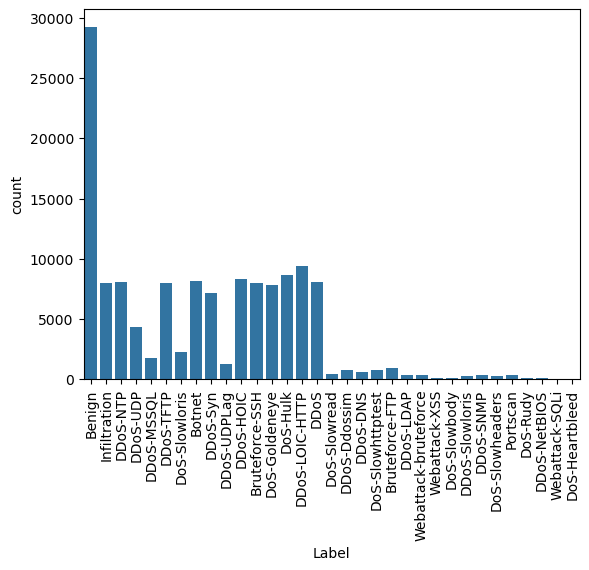

In [36]:
sns.countplot(val_set,x=label_col);
plt.xticks(rotation=90)
plt.show();

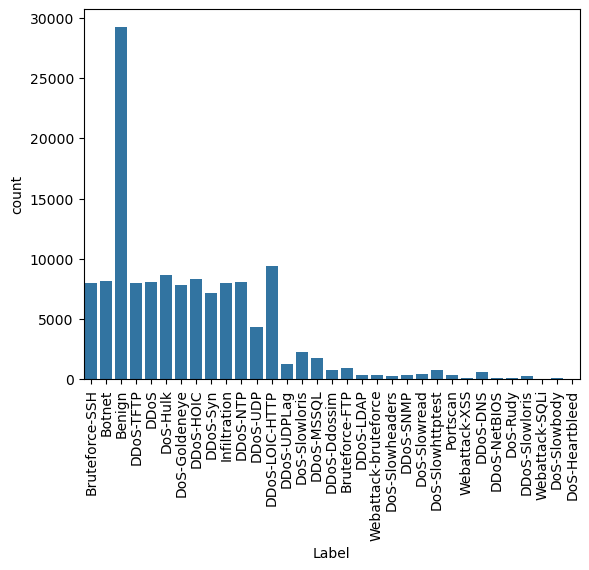

In [37]:
sns.countplot(test_set,x=label_col);
plt.xticks(rotation=90)
plt.show();

In [38]:
TARGET_LIST = le.classes_
TARGET_LIST

array(['Benign', 'Botnet', 'Bruteforce-FTP', 'Bruteforce-SSH', 'DDoS',
       'DDoS-DNS', 'DDoS-Ddossim', 'DDoS-HOIC', 'DDoS-LDAP',
       'DDoS-LOIC-HTTP', 'DDoS-MSSQL', 'DDoS-NTP', 'DDoS-NetBIOS',
       'DDoS-SNMP', 'DDoS-Slowloris', 'DDoS-Syn', 'DDoS-TFTP', 'DDoS-UDP',
       'DDoS-UDPLag', 'DoS-Goldeneye', 'DoS-Heartbleed', 'DoS-Hulk',
       'DoS-Rudy', 'DoS-Slowbody', 'DoS-Slowheaders', 'DoS-Slowhttptest',
       'DoS-Slowloris', 'DoS-Slowread', 'Infiltration', 'Portscan',
       'Webattack-SQLi', 'Webattack-XSS', 'Webattack-bruteforce'],
      dtype=object)

In [39]:
data[data[label_col]=='Uploading'].head(5)

,raw_input,Label,target


##BBPE algorithm

In [40]:
device = torch.device("cuda" if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

In [41]:
from tokenizers import Tokenizer, models
from tokenizers import ByteLevelBPETokenizer
tokenizer = ByteLevelBPETokenizer()

In [42]:
SPECIAL_TOKENS = [
    '<pad>',
    '<s>',
    '</s>',
    '<mask>',
    '<unk>'
]
VOCAB_SIZE = 10000
EMBED_DIM = 768     # or whatever you configure BERT with

In [43]:
import random

def sample_random_lines(file_path, num_lines=200000, seed=42):
    # Step 1: Count total lines
    with open(file_path, 'r', encoding='utf-8') as f:
        total_lines = sum(1 for _ in f)

    # Step 2: Sample random line numbers
    random.seed(seed)
    sampled_indices = set(random.sample(range(total_lines), num_lines))

    # Step 3: Extract the sampled lines
    sampled_lines = []
    with open(file_path, 'r', encoding='utf-8') as f:
        for i, line in enumerate(f):
            if i in sampled_indices:
                sampled_lines.append(line.strip())
            if len(sampled_lines) == num_lines:
                break

    return sampled_lines

In [44]:
%%time
#tokenizer.train(f'{encoded_data_file_name}.txt',vocab_size=VOCAB_SIZE,min_frequency=2,
#                special_tokens=SPECIAL_TOKENS)

lines = sample_random_lines(f'{encoded_data_file_name}.txt', num_lines=200000)

# Now train the tokenizer
from tokenizers import Tokenizer, models, trainers, pre_tokenizers

tokenizer.pre_tokenizer = pre_tokenizers.Whitespace()

from tqdm import tqdm
tokenizer.train_from_iterator(tqdm(lines, desc="Training tokenizer"), vocab_size=VOCAB_SIZE, min_frequency=2, special_tokens=SPECIAL_TOKENS)

Training tokenizer: 100%|██████████| 200000/200000 [00:00<00:00, 205322.43it/s]


CPU times: total: 1min 1s
Wall time: 9.91 s


os.mkdir('tokenizer')

In [45]:
save_dir = tokenizer_file_name
# Create the directory if it doesn't exist
os.makedirs(save_dir, exist_ok=True)
tokenizer.save_model(tokenizer_file_name)

['./tokenizer_CICIDS2017_raw_0.02samples\\vocab.json',
 './tokenizer_CICIDS2017_raw_0.02samples\\merges.txt']

##Model section

In [46]:
tokenizer = RobertaTokenizer.from_pretrained(tokenizer_file_name)

In [47]:
len(tokenizer.get_vocab())

10000

In [48]:
SPECIAL_TOKEN_IDS = {
    "cls": tokenizer.convert_tokens_to_ids("<s>"),
    "sep": tokenizer.convert_tokens_to_ids("</s>"),
    "pad": tokenizer.pad_token_id,
    "unk": tokenizer.unk_token_id,
    "mask": tokenizer.mask_token_id
}

In [49]:
def get_pretrain_columns(tmp_set):
    # Indices to keep
    selected_indices = [1, 2, 27, 34, 35, 54]

    # Payload
    tmp_set['payload'] = tmp_set['raw_input'].apply(
        lambda x: ' '.join([x.split()[i] for i in [32] if i < len(x.split())])
    )

    # Apply the transformation to each row in the column
    tmp_set['raw_input'] = tmp_set['raw_input'].apply(
        lambda x: ' '.join([x.split()[i] for i in selected_indices if i < len(x.split())])
    )

    return tmp_set

In [50]:
from copy import deepcopy

train_set_pretrain = deepcopy(train_set)
train_set_pretrain = train_set_pretrain.drop(columns={"target", "Label"})
val_set_pretrain = deepcopy(val_set)
val_set_pretrain = val_set_pretrain.drop(columns={"target", "Label"})
test_set_pretrain = deepcopy(test_set)
test_set_pretrain = test_set_pretrain.drop(columns={"target", "Label"})

In [51]:
def build_input_sequence(sentence_a, sentence_b=None, max_len=128):
    #print(sentence_a, sentence_b)
    tokens = ["<s>"]
    segment_ids = [0]

    for word in sentence_a:
        tokens.append(word)
        #assert all(0 <= t < VOCAB_SIZE+5 for t in tokens), f"Token ID out of range: {tokens}"
        segment_ids.append(0)

    if sentence_b:
        tokens.append("</s>")
        segment_ids.append(0)

        for word in sentence_b:
            tokens.append(word)
            #assert all(0 <= t < VOCAB_SIZE+5 for t in tokens), f"Token ID out of range: {tokens}"
            segment_ids.append(1)

        tokens.append("</s>")
        segment_ids.append(1)
    else:
        tokens.append("</s>")
        segment_ids.append(0)

    # Padding
    if len(tokens) < max_len:
        pad_len = max_len - len(tokens)
        tokens += ["<pad>"] * pad_len
        segment_ids += [0] * pad_len
    token_ids = tokenizer.convert_tokens_to_ids(tokens[:max_len])

    # print("Tokens:", tokens[:max_len])
    # print("Token IDs:", tokenizer.convert_tokens_to_ids(tokens[:max_len]))

    return torch.tensor(token_ids), torch.tensor(segment_ids[:max_len])


In [52]:
MASK_TOKEN_ID = SPECIAL_TOKEN_IDS["mask"]
PAD_TOKEN_ID = SPECIAL_TOKEN_IDS["pad"]

class IoVPretrainDataset(Dataset):
    def __init__(self, sentence_pairs, vocab_size=VOCAB_SIZE, max_len=512, mask_prob=0.15):
        """
        sentence_pairs: list of {"byte_sentence_a": [...], "byte_sentence_b": [...], "is_next": bool}
        """
        self.sentence_pairs = sentence_pairs
        self.vocab_size = vocab_size
        self.max_len = max_len
        self.mask_prob = mask_prob

    def __len__(self):
        return len(self.sentence_pairs)

    def __getitem__(self, idx):
        item = self.sentence_pairs[idx]
        sentence_a = item["byte_sentence_a"]
        sentence_b = item["byte_sentence_b"]
        is_next = item.get("is_next", 1)  # 1: true next sentence, 0: random sentence

        #print("__getitem__() sentence_a: ")
        #print(f"{item["byte_sentence_a"]}")
        token_ids, segment_ids = build_input_sequence(sentence_a, sentence_b, self.max_len)
        masked_token_ids, labels = self.apply_masking(token_ids)
        assert not torch.isnan(masked_token_ids).any()
        assert not torch.isinf(masked_token_ids).any()
        attention_mask = (masked_token_ids != PAD_TOKEN_ID).long()
        assert masked_token_ids.max() < self.vocab_size, f"Found token ID {masked_token_ids.max()} >= vocab_size {self.vocab_size}"
        if (attention_mask != -100).sum() == 0:
            print("All MLM labels are -100 — skipping loss")

        return {
            "input_ids": masked_token_ids,
            "attention_mask": attention_mask,
            "token_type_ids": segment_ids,
            "labels": labels,
            "nsp_labels": torch.tensor(is_next, dtype=torch.long)
        }

    def apply_masking(self, token_ids: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
        """
        Apply 15% masking to token_ids.
        Returns:
            - masked_input_ids
            - labels (only non -100 positions are used in loss)
        """
        input_ids = token_ids.clone()
        labels = torch.full(input_ids.shape, -100)  # default ignore index

        for i in range(1, len(input_ids)):  # skip [CLS]
            if input_ids[i].item() in SPECIAL_TOKEN_IDS.values():
                continue

            if random.random() < self.mask_prob:
                labels[i] = input_ids[i].item()  # save original for prediction

                rand_val = random.random()
                if rand_val < 0.8:
                    input_ids[i] = MASK_TOKEN_ID
                elif rand_val < 0.9:
                    input_ids[i] = random.randint(0, self.vocab_size - 1)
                else:
                    pass  # keep original

        if (labels != -100).sum() == 0:
            for i in range(1, len(input_ids)):
                if input_ids[i].item() not in SPECIAL_TOKEN_IDS.values():
                    labels[i] = input_ids[i].item()
                    input_ids[i] = MASK_TOKEN_ID
                    break
        return input_ids, labels


##Dataset and DataLoader

In [53]:
class CustomDataset(Dataset):
  def __init__(self,df,tokenizer,max_len):
    self.df = df
    self.tokenizer = tokenizer
    self.max_len=max_len
    self.sequence = self.df['raw_input'].tolist()
    self.targets = self.df['target'].tolist()

  def __len__(self):
    return len(self.df)

  def __getitem__(self,idx):
    sequence = str(self.sequence[idx])
    target = self.targets[idx]
    encoding = self.tokenizer.encode_plus(
        sequence,
        add_special_tokens=True,
        max_length=self.max_len,
        padding='max_length',
        return_token_type_ids=False,
        truncation=True,
        return_attention_mask=True,
        return_tensors='pt'
    )

    return {
        'input_ids':encoding['input_ids'].flatten(),
        'attention_mask':encoding['attention_mask'].flatten(),
        'targets':torch.tensor(target,dtype=torch.long)
    }


In [54]:
class BidirectionalSemanticExtractor:
    def __init__(self, columns = ["src_ip", "dst_ip", "src_port", "dst_port", "protocol"], window_size=2, step_size=1):
        self.window_size = window_size
        self.step_size = step_size
        self.columns = columns

    def extract_sessions(self, packets: list[dict]) -> dict:
        """
        Organizes packets into sessions based on a tuple
        Each packet is assumed to be a dictionary with necessary fields.
        """
        sessions = {}
        for pkt in packets:
            key = tuple(pkt[col] for col in self.columns)
            sessions.setdefault(key, []).append(pkt)
        return sessions

    def sliding_window_pairs(self, session_packets: list[dict]) -> list[tuple[list[str], list[str]]]:
        """
        Generates byte sentence pairs (sentence_a, sentence_b) using USE.
        """
        pairs = []
        #print(f"sliding_window_pairs() -> len(session_packets) - self.window_size + 1 = {len(session_packets) - self.window_size + 1}")
        for i in range(0, len(session_packets) - self.window_size + 1, self.step_size):
            # print("reached sliding_window_pairs() loop")
            pkt_a = session_packets[i]
            pkt_b = session_packets[i + 1]
            sentence_a = pkt_a["payload"].split()
            sentence_b = pkt_b["payload"].split()
            pairs.append((sentence_a, sentence_b))
        return pairs

    def process(self, packets: list[dict]) -> list[dict]:
        """
        Main function to extract training samples from raw packet list.
        Returns a list of training samples with byte_sentence_a and byte_sentence_b.
        """
        bsl = []
        """
        print("Before extract_sessions()")
        # Randomly sample 2 rows
        sampled = random.sample(packets, 2)
        # Print sampled rows
        for row in sampled:
            print(row)
        """
        sessions = self.extract_sessions(packets)
        """
        print("After extract_sessions()")
        if len(sessions) >= 2:
            sampled_items = random.sample(list(sessions.items()), 2)
            for key, value in sampled_items:
                print(f"{key}: {value}")
        else:
            print(f"Not enough sessions to sample from. Only {len(sessions)} available.")
        """

        for session_key, pkt_list in sessions.items():
            #print(f"len(pkt_list) = {len(pkt_list)}")
            pairs = self.sliding_window_pairs(pkt_list)
            for sa, sb in pairs:
                bsl.append({
                    "byte_sentence_a": sa,
                    "byte_sentence_b": sb
                })
        #print("After loop in process()")
        return bsl


In [55]:
class IoVInputEmbedding(nn.Module):
    def __init__(self, vocab_size=VOCAB_SIZE, embed_dim=EMBED_DIM, max_len=512):
        super().__init__()
        self.token_embedding = nn.Embedding(vocab_size, embed_dim)
        self.segment_embedding = nn.Embedding(2, embed_dim)  # 0: sentence A, 1: sentence B
        self.position_embedding = nn.Embedding(max_len, embed_dim)

    def forward(self, token_ids: torch.Tensor, segment_ids: torch.Tensor):
        """
        token_ids: (batch_size, seq_len)
        segment_ids: (batch_size, seq_len)
        Returns:
            embeddings: (batch_size, seq_len, embed_dim)
        """

        assert (token_ids < VOCAB_SIZE).all(), \
            f"Found input_ids >= vocab_size ({VOCAB_SIZE})"

        seq_len = token_ids.size(1)
        position_ids = torch.arange(seq_len, dtype=torch.long, device=token_ids.device)
        position_ids = position_ids.unsqueeze(0).expand_as(token_ids)

        token_embed = self.token_embedding(token_ids)
        segment_embed = self.segment_embedding(segment_ids)
        position_embed = self.position_embedding(position_ids)

        return token_embed + segment_embed + position_embed


In [56]:
MAX_LEN=512
BATCH_SIZE=32

In [57]:
train_dataset = CustomDataset(train_set,tokenizer=tokenizer,max_len=MAX_LEN)
val_dataset = CustomDataset(val_set,tokenizer=tokenizer,max_len=MAX_LEN)
test_dataset = CustomDataset(test_set,tokenizer=tokenizer,max_len=MAX_LEN)

In [58]:
train_loader = DataLoader(
    train_dataset,
    shuffle=True,
    batch_size=BATCH_SIZE,
    num_workers=0

)

val_loader = DataLoader(
    val_dataset,
    shuffle=False,
    batch_size=BATCH_SIZE,
    num_workers=0

)

test_loader = DataLoader(
    test_dataset,
    shuffle=False,
    batch_size=BATCH_SIZE,
    num_workers=0

)

#Fine tuning BERT

In [59]:
config = AutoConfig.from_pretrained("bert-base-uncased")
config

BertConfig {
  "architectures": [
    "BertForMaskedLM"
  ],
  "attention_probs_dropout_prob": 0.1,
  "classifier_dropout": null,
  "gradient_checkpointing": false,
  "hidden_act": "gelu",
  "hidden_dropout_prob": 0.1,
  "hidden_size": 768,
  "initializer_range": 0.02,
  "intermediate_size": 3072,
  "layer_norm_eps": 1e-12,
  "max_position_embeddings": 512,
  "model_type": "bert",
  "num_attention_heads": 12,
  "num_hidden_layers": 12,
  "pad_token_id": 0,
  "position_embedding_type": "absolute",
  "transformers_version": "4.53.0.dev0",
  "type_vocab_size": 2,
  "use_cache": true,
  "vocab_size": 30522
}

In [60]:
config.hidden_size = 256
config.num_hidden_layers = 4
config.num_attention_heads = 16
config.intermediate_size = 512
config.vocab_size=VOCAB_SIZE


In [61]:
finetunedBERT = AutoModel.from_config(config)

In [62]:
finetunedBERT

BertModel(
  (embeddings): BertEmbeddings(
    (word_embeddings): Embedding(10000, 256, padding_idx=0)
    (position_embeddings): Embedding(512, 256)
    (token_type_embeddings): Embedding(2, 256)
    (LayerNorm): LayerNorm((256,), eps=1e-12, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (encoder): BertEncoder(
    (layer): ModuleList(
      (0-3): 4 x BertLayer(
        (attention): BertAttention(
          (self): BertSdpaSelfAttention(
            (query): Linear(in_features=256, out_features=256, bias=True)
            (key): Linear(in_features=256, out_features=256, bias=True)
            (value): Linear(in_features=256, out_features=256, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (output): BertSelfOutput(
            (dense): Linear(in_features=256, out_features=256, bias=True)
            (LayerNorm): LayerNorm((256,), eps=1e-12, elementwise_affine=True)
            (dropout): Dropout(p=0.1, inplace=False)


###Model paramerters

In [63]:
sum(p.numel() for p in finetunedBERT.parameters())

4866304

##Model definition

In [64]:
class SecurityBERT(nn.Module):
  def __init__(self,finetunedBERT,n_classes):
    super(SecurityBERT,self).__init__()
    self.bert = finetunedBERT
    self.dropout = nn.Dropout(p=0.1)
    self.out = nn.Linear(self.bert.config.hidden_size,n_classes)

  def forward(self,input_ids,attention_mask):
    pooled_output = self.bert(
        input_ids=input_ids,
        attention_mask=attention_mask
    ).pooler_output

    output = self.dropout(pooled_output)

    return self.out(output)


test_data = next(iter(train_loader))

print(test_data['input_ids'].shape)

In [65]:
# input_ids = test_data['input_ids'].to(device)
# attention_mask = test_data['attention_mask'].to(device)

# res = nn.functional.softmax(securityBert(input_ids,attention_mask),dim=1)


###Subsection of training


In [66]:
def load_chkpt(model,version):
  return model.load_state_dict(torch.load(f"./saved_model/securityBert4_CICIDS2017_{version}.0.pt",map_location=torch.device('cpu')))

##Training and Evaluation

In [67]:
def train_model(model,data_loader,loss_fn,optimizer,device,scheduler,n_examples):
  model = model.train()

  losses = []
  correct_predictions = 0

  for d in data_loader:
    input_ids = d['input_ids'].to(device)
    attention_mask = d['attention_mask'].to(device)
    targets = d['targets'].to(device)

    outputs = model(input_ids,attention_mask)
    _,preds = torch.max(outputs,dim=1)
    loss = loss_fn(outputs,targets)

    correct_predictions+=torch.sum(preds==targets).cpu()

    losses.append(loss.item())

    loss.backward()
    nn.utils.clip_grad_norm(model.parameters(),max_norm=1.0)

    optimizer.step()
    scheduler.step()

    optimizer.zero_grad()

  return correct_predictions/n_examples,np.mean(losses)

In [68]:
def evaluation_model(model,data_loader,loss_fn,device,n_examples):
  model = model.train()

  losses = []
  correct_predictions = 0

  for d in data_loader:
    input_ids = d['input_ids'].to(device)
    attention_mask = d['attention_mask'].to(device)
    targets = d['targets'].to(device)

    outputs = model(input_ids,attention_mask)
    _,preds = torch.max(outputs,dim=1)

    loss = loss_fn(outputs,targets)

    correct_predictions+=torch.sum(preds==targets).cpu()

    losses.append(loss.item())

  return correct_predictions/n_examples,np.mean(losses)

In [69]:
class IoVPipeline:
    def __init__(self, columns, embedding_dim=768, max_seq_len=128, vocab_size=VOCAB_SIZE, device=None):
        self.bse = BidirectionalSemanticExtractor(columns)
        self.embedding_model = IoVInputEmbedding(embed_dim=embedding_dim, max_len=max_seq_len)
        self.max_seq_len = max_seq_len
        self.vocab_size = vocab_size
        self.best_pretrain_val_acc = 0.0
        self.best_tune_val_acc = 0.0

        self.device = device or torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.model = self._init_model().to(self.device)
        self.test_loader = DataLoader(TensorDataset(torch.empty(0)))

        self.pretrain_history = {
            "train_loss": [],
            "train_acc": [],
            "val_loss": [],
            "val_acc": [],
            "total_time": None
        }
        self.tune_history = {
            "train_loss": [],
            "train_acc": [],
            "val_loss": [],
            "val_acc": [],
            "total_time": None
        }

    def _init_model(self):
        config = AutoConfig.from_pretrained("bert-base-uncased")
        config.hidden_size = 256
        config.num_hidden_layers = 4
        config.num_attention_heads = 16
        config.intermediate_size = 512
        config.vocab_size=len(tokenizer)
        config.cls_token_id=tokenizer.convert_tokens_to_ids("<s>")
        config.sep_token_id=tokenizer.convert_tokens_to_ids("</s>")
        config.pad_token_id=tokenizer.convert_tokens_to_ids("<pad>")
        config.mask_token_id=tokenizer.convert_tokens_to_ids("<mask>")
        config.unk_token_id=tokenizer.convert_tokens_to_ids("<unk>")
        model = BertForPreTraining(config)
        model.resize_token_embeddings(len(tokenizer)) # In case BertForPreTraining defaults mess up vocab_size
        print(len(tokenizer))
        return model

    def process_packets(self, raw_packets: list[dict], mode="pretrain"):
        if mode == "pretrain":
            bsl = self.bse.process(raw_packets)
            return self._generate_nsp_pairs(bsl)
        else:
            processed = []
            for pkt in raw_packets:
                if "can_id" in pkt:
                    sentence = self.use.extract_from_can(pkt["can_id"], pkt["data"])
                else:
                    sentence = self.use.extract_from_extra_vehicle(pkt["payload"])
                processed.append({
                    "byte_sentence_a": sentence,
                    "label": pkt["label"]
                    })
            return processed

    def _generate_nsp_pairs(self, bsl: list[dict]) -> list[dict]:
        positives = [{"byte_sentence_a": d["byte_sentence_a"], "byte_sentence_b": d["byte_sentence_b"], "is_next": 1} for d in bsl]
        sentence_bs = [d["byte_sentence_b"] for d in bsl]
        random.shuffle(sentence_bs)
        negatives = [{"byte_sentence_a": bsl[i]["byte_sentence_a"], "byte_sentence_b": sentence_bs[i], "is_next": 0} for i in range(len(bsl))]
        combined = positives + negatives
        random.shuffle(combined)
        return combined

    def prepare_pretrain_dataloader(self, train, val, test, batch_size=16, val_split=0.15, test_split=0.15):
        train_pdataset = IoVPretrainDataset(self.process_packets(train, mode="pretrain"), vocab_size=self.vocab_size, max_len=self.max_seq_len)
        val_pdataset = IoVPretrainDataset(self.process_packets(val, mode="pretrain"), vocab_size=self.vocab_size, max_len=self.max_seq_len)
        test_pdataset = IoVPretrainDataset(self.process_packets(test, mode="pretrain"), vocab_size=self.vocab_size, max_len=self.max_seq_len)

        print(f"Train samples before DataLoader: {len(train_pdataset)}")
        
        train_ploader = DataLoader(train_pdataset, batch_size=batch_size, shuffle=True)
        val_ploader = DataLoader(val_pdataset, batch_size=batch_size, shuffle=False)
        test_ploader = DataLoader(test_pdataset, batch_size=batch_size, shuffle=False)
        
        return train_ploader, val_ploader, test_ploader
    
    def prepare_tune_dataloader(self, raw_packets, batch_size=16, val_split=0.15, test_split=0.15):
        processed_packets = self.process_packets(raw_packets, mode="finetune")
        print("Sample processed packet:", processed_packets[0])
        dataset = IoVIDSFinetuneDataset(processed_packets, vocab_size=self.vocab_size, max_len=self.max_seq_len)
        
        total_len = len(dataset)
        val_len = int(val_split * total_len)
        test_len = int(test_split * total_len)
        train_len = total_len - val_len - test_len
        
        train_set, val_set, test_set = random_split(dataset, [train_len, val_len, test_len], generator=torch.Generator().manual_seed(42))
        
        train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True)
        val_loader = DataLoader(val_set, batch_size=batch_size, shuffle=False)
        test_loader = DataLoader(test_set, batch_size=batch_size, shuffle=False)
        
        return train_loader, val_loader, test_loader

    def pretrain(self, train, val, test, model_directory, model_version, epochs=10, batch_size=16, lr=5e-5, device=device):
        train_loader, val_loader, self.test_loader = self.prepare_pretrain_dataloader(train, val, test, batch_size=batch_size)
        optimizer = AdamW(self.model.parameters(), lr=lr)
        start_time = time.time()

        for epoch in range(epochs):
            train_loss, train_acc = self._run_epoch(train_loader, optimizer, is_train=True)
            val_loss, val_acc = self._run_epoch(val_loader, optimizer=None, is_train=False)

            self.pretrain_history["train_loss"].append(train_loss)
            self.pretrain_history["train_acc"].append(train_acc)
            self.pretrain_history["val_loss"].append(val_loss)
            self.pretrain_history["val_acc"].append(val_acc)

            print(f"Epoch {epoch+1}/{epochs} | Train Loss: {train_loss:.4f}, Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f}, Acc: {val_acc:.4f}")

            if val_acc > self.best_pretrain_val_acc:
                self.best_pretrain_val_acc = val_acc
                self.model.save_pretrained(f"./{model_directory}{model_version}{epoch+1}.0/")
                print(f"Saved best model at epoch {epoch+1} with val_acc={val_acc:.4f}")

        self.pretrain_history["total_time"] = time.time() - start_time

    def _run_epoch(self, dataloader, optimizer=None, is_train=True):
        for i, batch in enumerate(dataloader):
            for k, v in batch.items():
                if isinstance(v, torch.Tensor):
                    if torch.isnan(v).any():
                        print(f"NaN detected in {k}")
                    if torch.isinf(v).any():
                        print(f"Inf detected in {k}")
                    if v.min() < 0 and k == "input_ids":
                        print("Negative token ID in input_ids")

            break  # Check only the first batch for now
        
        if is_train:
            self.model.train()
        else:
            self.model.eval()

        total_loss = 0.0
        correct_tokens = 0
        total_tokens = 0
        correct_nsp = 0
        total_nsp = 0

        loop = tqdm(dataloader, desc="Training" if is_train else "Validation", leave=True)

        for batch in loop:
            # Prepare inputs dict
            inputs = {k: v.to(self.device) for k, v in batch.items() if k not in ["nsp_labels", "next_sentence_label", "segment_ids"]}

            input_ids = batch["input_ids"]

            assert input_ids.max().item() < self.model.config.vocab_size, \
                f"input_ids contain out-of-range token: {input_ids.max().item()} >= {self.model.config.vocab_size}"

            # segment_ids should be renamed to token_type_ids
            if "segment_ids" in batch:
                inputs["token_type_ids"] = batch["segment_ids"].to(self.device)
    
            # Initialize next_sentence_label to None
            next_sentence_label = None
            
            # Check for next sentence label keys
            if "nsp_labels" in batch:
                next_sentence_label = batch["nsp_labels"]
            elif "next_sentence_label" in batch:
                next_sentence_label = batch["next_sentence_label"]
            
            # Add to inputs if present
            if next_sentence_label is not None:
                inputs["next_sentence_label"] = next_sentence_label.to(self.device)

            if is_train:
                optimizer.zero_grad()

            outputs = self.model(**inputs)
            if torch.isnan(outputs.loss) or torch.isinf(outputs.loss):
                print("NaN or Inf loss detected — skipping batch")
                continue  # or return zero loss, etc.

            if torch.isnan(outputs.loss) or torch.isinf(outputs.loss):
                print("NaN loss detected in model forward pass")
                print("Inputs:")
                for k, v in inputs.items():
                    print(f"{k}: {v.shape}, NaN: {torch.isnan(v).any()}, Inf: {torch.isinf(v).any()}")
                return float('nan'), float('nan')  # Early exit


            loss = outputs.loss
            prediction_logits = outputs.prediction_logits
            seq_labels = batch["labels"].to(self.device)

            if is_train:
                loss.backward()
                optimizer.step()

            total_loss += loss.item()

            # Calculate accuracy for tokens (MLM)
            pred_tokens = prediction_logits.argmax(dim=-1)
            
            masked_mask = seq_labels != -100
            masked_preds = pred_tokens[masked_mask]
            masked_labels = seq_labels[masked_mask]

            correct_tokens += (masked_preds == masked_labels).sum().item()
            total_tokens += masked_labels.numel()

            # Calculate accuracy for NSP
            pred_nsp = outputs.seq_relationship_logits.argmax(dim=-1)
            if next_sentence_label is not None:
                correct_nsp += (pred_nsp == next_sentence_label.to(self.device)).sum().item()
                total_nsp += next_sentence_label.size(0)

            # Update tqdm postfix with loss and accuracies
            loop.set_postfix(loss=loss.item(),
                            token_acc=correct_tokens / (total_tokens + 1e-8),
                            nsp_acc=(correct_nsp / (total_nsp + 1e-8) if total_nsp > 0 else 0))

        avg_loss = total_loss / len(dataloader)
        token_acc = correct_tokens / (total_tokens + 1e-8)
        nsp_acc = (correct_nsp / (total_nsp + 1e-8)) if total_nsp > 0 else 0

        return avg_loss, (token_acc + nsp_acc) / 2

In [70]:
def separate_input_data(row, columns):
    tokens = row['raw_input'].split()
    selected_indices = [45, 46]
    selected_tokens = [tokens[i] for i in selected_indices]
    
    return pd.Series(selected_tokens, index=columns)

In [71]:
def final_pretraining_data_preparation(df, columns):
    df[columns] = df.apply(lambda row: separate_input_data(row, columns), axis=1)
    df = df.rename(columns={"raw_input": "payload"})
    return df

In [72]:
def clean_float_str(x):
    return ('{:.10f}'.format(x)).rstrip('0').rstrip('.')  # Keeps precision up to 10 digits, then trims

In [73]:
num_epochs=3
figure_version = f"SecurityBERT4 CIC-IDS-2017 (Modified) {clean_float_str(keep_frac * 100)}% Samples Pre-training"
figure_file_name = f'bertPretrained-securityBert4-mod-raw-Cicids2017-{keep_frac}samples'
model_version = f"bertPretrained_securityBERT4_mod_raw_CICIDS2017_{keep_frac}samples"
model_directory = "pretrained_model/"
reduced_columns = ['Init Fwd Win Bytes', 'Init Bwd Win Bytes']
print("Before final_pretraining_data_preparation():")
print(train_set_pretrain.sample(2))
train_set_pretrain = final_pretraining_data_preparation(train_set_pretrain, reduced_columns)
val_set_pretrain = final_pretraining_data_preparation(val_set_pretrain, reduced_columns)
test_set_pretrain = final_pretraining_data_preparation(test_set_pretrain, reduced_columns)
print("After final_pretraining_data_preparation():")
print(train_set_pretrain.sample(2))

Before final_pretraining_data_preparation():
                                                raw_input
157848  826 3 4 148.0 243.0 148.0 49.33333206176758 85...
526930  914 26 0 11440.0 0.0 440.0 440.0 0.0 0.0 0.0 0...
After final_pretraining_data_preparation():
                                                  payload Init Fwd Win Bytes  \
400831  10286 3 4 326.0 129.0 326.0 108.66666412353516...               8192   
544631  3003662 4 0 2064.0 0.0 516.0 516.0 0.0 0.0 0.0...                 -1   

       Init Bwd Win Bytes  
400831                219  
544631                 -1  


In [74]:
pipeline = IoVPipeline(reduced_columns)

10000


In [75]:
train_set_pretrain.columns

Index(['payload', 'Init Fwd Win Bytes', 'Init Bwd Win Bytes'], dtype='object')

In [76]:
pipeline.pretrain(train_set_pretrain.to_dict(orient="records"), val_set_pretrain.to_dict(orient="records"), test_set_pretrain.to_dict(orient="records"), 
                  epochs=num_epochs, batch_size=4, model_directory = model_directory, model_version=model_version + "_")
torch.save(pipeline.pretrain_history, f"./{model_directory}history_{model_version}.pt")

Train samples before DataLoader: 1228100


Validation: 100%|██████████| 64923/64923 [15:54<00:00, 68.02it/s, loss=0.000785, nsp_acc=0.952, token_acc=0.931]


Epoch 1/3 | Train Loss: 0.6680, Acc: 0.9232 | Val Loss: 0.5087, Acc: 0.9413
Saved best model at epoch 1 with val_acc=0.9413


Validation: 100%|██████████| 64923/64923 [15:57<00:00, 67.78it/s, loss=0.000611, nsp_acc=0.952, token_acc=0.936]


Epoch 2/3 | Train Loss: 0.5200, Acc: 0.9410 | Val Loss: 0.4952, Acc: 0.9440
Saved best model at epoch 2 with val_acc=0.9440


Validation: 100%|██████████| 64923/64923 [15:52<00:00, 68.16it/s, loss=0.118, nsp_acc=0.951, token_acc=0.938]   


Epoch 3/3 | Train Loss: 0.5065, Acc: 0.9429 | Val Loss: 0.4801, Acc: 0.9447
Saved best model at epoch 3 with val_acc=0.9447


In [77]:
# Save the indices of the test set (relative to the original df)
test_indices = test_set_pretrain.index.to_numpy()
np.save(f"./pretrained_model/test_indices_{model_version}.npy", test_indices)

In [78]:
# Load
pretraining_history = torch.load(f"./pretrained_model/history_{model_version}.pt", weights_only=False)

# Still a defaultdict with tensors
print(type(pretraining_history))  # defaultdict
print(type(pretraining_history['train_acc'][0]))  # torch.Tensor

<class 'dict'>
<class 'float'>


In [79]:
# Inspect keys and sample values
history_keys = list(pretraining_history.keys())
sample_values = {
    k: pretraining_history[k][:3] if isinstance(pretraining_history[k], list) else pretraining_history[k]
    for k in history_keys
}

print("Available keys:", history_keys)
for key, value in sample_values.items():
    print(f"{key}: {value}")

Available keys: ['train_loss', 'train_acc', 'val_loss', 'val_acc', 'total_time']
train_loss: [0.6679615173108759, 0.5199763767062142, 0.5064766176543086]
train_acc: [0.9231869752269731, 0.9410166828851161, 0.9429463850974715]
val_loss: [0.5087304100696596, 0.4952324820792632, 0.4800764041791455]
val_acc: [0.9413003803406641, 0.9440206188708811, 0.9447195825532917]
total_time: 26714.66534423828


[0.6679615173108759, 0.5199763767062142, 0.5064766176543086]
[0.5087304100696596, 0.4952324820792632, 0.4800764041791455]


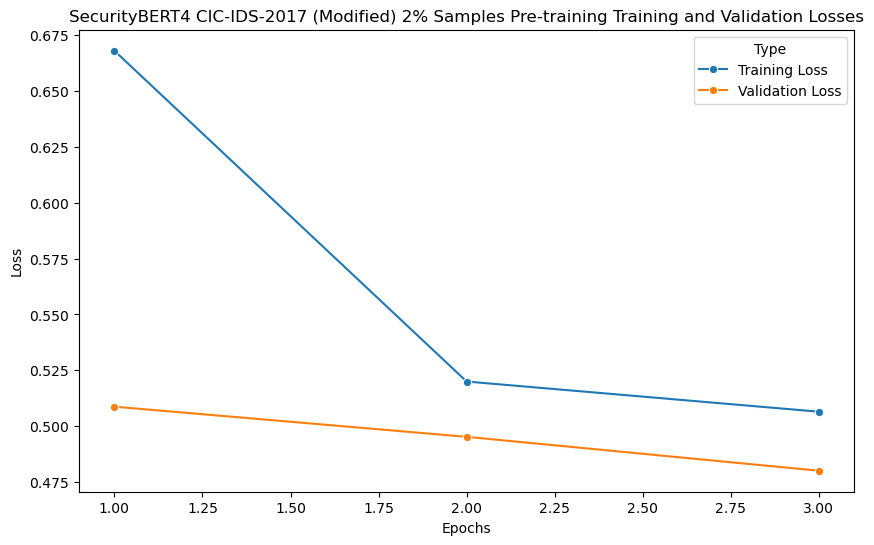

In [80]:
import matplotlib.pyplot as plt
import seaborn as sns

epochs = range(1, len(pretraining_history['train_acc'])+1)
train_losses = pretraining_history['train_loss']
print(train_losses)
val_losses = pretraining_history['val_loss']
print(val_losses)

df_plot = pd.DataFrame({
    "Epoch": epochs,
    "Training Loss": train_losses,
    "Validation Loss": val_losses
})

# Melt to long-form for seaborn
df_plot_long = df_plot.melt(id_vars="Epoch", var_name="Type", value_name="Loss")

plt.figure(figsize=(10, 6))
sns.lineplot(data=df_plot_long, x="Epoch", y="Loss", hue="Type", marker="o")
plt.title(f'{figure_version} Training and Validation Losses')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.savefig(f'./{figure_file_name}-{num_epochs}ep-training-validation-losses.png', dpi=780)
plt.show()

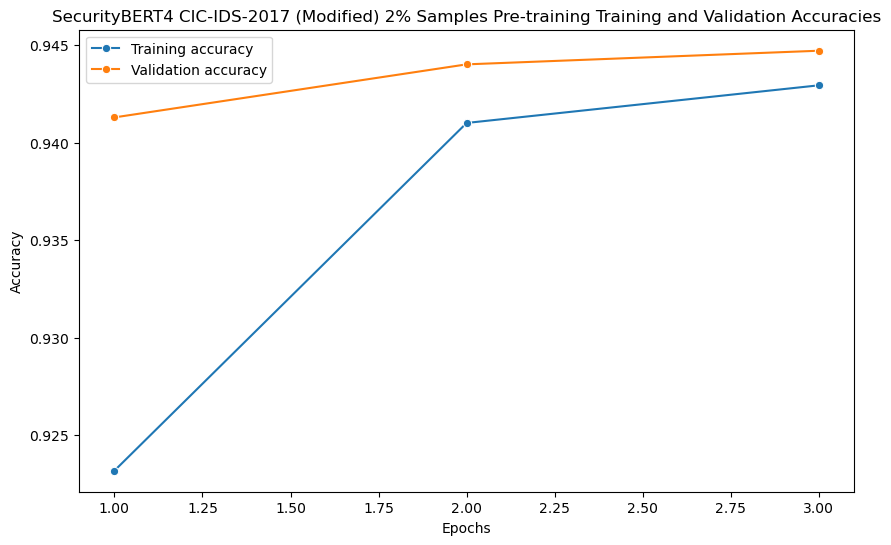

In [81]:
epochs = range(1, len(pretraining_history['train_acc'])+1)
train_accuracies = pretraining_history['train_acc']
val_accuracies = pretraining_history['val_acc']

plt.figure(figsize=(10, 6))

sns.lineplot(x=epochs, y=train_accuracies, label='Training accuracy',marker='o', data=None)
sns.lineplot(x=epochs, y=val_accuracies, label='Validation accuracy',marker='o', data=None)

plt.title(f'{figure_version} Training and Validation Accuracies')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.savefig(f'./{figure_file_name}-{num_epochs}ep-training-validation-accuracies.png',dpi=780)
plt.show()

In [82]:
def get_predictions(model,test_loader):
    model = model.eval()

    predictions,predictions_probs,real_values = [],[],[]

    with torch.no_grad():
        for data in tqdm(test_loader,desc="Predictions"):
            input_ids = data['input_ids'].to(device)
            attention_mask = data['attention_mask'].to(device)
            targets = data['targets'].to(device)

            outputs = model(input_ids,attention_mask)
            _,preds = torch.max(outputs,dim=1)

            probs = F.softmax(outputs,dim=1)

            predictions.extend(preds)
            predictions_probs.extend(probs)
            real_values.extend(targets)

    predictions = torch.stack(predictions).cpu()
    predictions_probs = torch.stack(predictions_probs).cpu()
    real_values = torch.stack(real_values).cpu()

    return predictions,predictions_probs,real_values



## Fine-tuning

In [83]:
def load_pretrained_model_checkpoint():
    base_path = "pretrained_model"
    filenames = [
        f"bertPretrained_securityBERT4_mod_raw_CICIDS2017_{keep_frac}samples_3.0/",
        f"bertPretrained_securityBERT4_mod_raw_CICIDS2017_{keep_frac}samples_2.0/",
        f"bertPretrained_securityBERT4_mod_raw_CICIDS2017_{keep_frac}samples_1.0/",
    ]

    for filename in filenames:
        full_path = os.path.join(base_path, filename)
        if os.path.exists(full_path):
            print(f"Loading checkpoint from: {full_path}")
            try:
                pretrainedBERT = BertModel.from_pretrained(full_path, local_files_only=True)
                return pretrainedBERT
            except Exception as e:
                print(f"Failed to load {full_path}: {e}")
                continue

    raise FileNotFoundError("No valid model checkpoint found for given keep_frac.")

In [84]:

finetunedBERT = load_pretrained_model_checkpoint()
model_directory = "finetuned_model/"
model_version = f"bertFinetuned_securityBERT4_mod_raw_CICIDS2017_{keep_frac}samples"
figure_version = f"SecurityBERT4 CIC-IDS-2017 (Modified) {clean_float_str(keep_frac * 100)}% Samples Fine Tuning"
figure_file_name = f'bertFinetuned-securityBert4-mod-raw-Cicids2017-{keep_frac}samples'
num_epochs=3

Loading checkpoint from: pretrained_model\bertPretrained_securityBERT4_mod_raw_CICIDS2017_0.02samples_3.0/


In [85]:
securityBert = SecurityBERT(finetunedBERT=finetunedBERT,n_classes=len(TARGET_LIST)).to(device)
EPOCHS=num_epochs
optimizer = torch.optim.AdamW(securityBert.parameters(),lr=1e-5)
total_steps = len(train_loader)*EPOCHS

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps= 0,
    num_training_steps=total_steps
)
loss_fn = nn.CrossEntropyLoss().to(device)

In [86]:
%%time
history = defaultdict(list)
best_accuracy=0

start_time = time.time()

for epoch in tqdm(range(EPOCHS)):
  print(f"Epoch {epoch+1}/{EPOCHS}")
  train_acc,train_loss = train_model(securityBert,train_loader,loss_fn,optimizer,device,scheduler,len(train_set))
  val_acc,val_loss = evaluation_model(securityBert,val_loader,loss_fn,device,len(val_set))
  history['train_acc'].append(train_acc)
  history['train_loss'].append(train_loss)
  history['val_acc'].append(val_acc)
  history['val_loss'].append(val_loss)
  print(f"Train Loss {train_loss} | Validation Loss {val_loss} |Training Accuracy {train_acc} |Validation Accuracy {val_acc}")

  if val_acc>best_accuracy:
    save_dir = './finetuned_model'
    # Create the directory if it doesn't exist
    os.makedirs(save_dir, exist_ok=True)
    torch.save(securityBert.state_dict(),f"./{model_directory}{model_version}_{epoch+1}.0.pt")
    best_accuracy = val_acc

history['training_time'].append(time.time() - start_time)

  0%|          | 0/3 [00:00<?, ?it/s]

Epoch 1/3


 33%|███▎      | 1/3 [47:38<1:35:17, 2858.81s/it]

Train Loss 0.49436558832784244 | Validation Loss 0.22529118056191338 |Training Accuracy 0.8676722049713135 |Validation Accuracy 0.9248192310333252
Epoch 2/3


 67%|██████▋   | 2/3 [1:33:23<46:31, 2791.95s/it]

Train Loss 0.18747418615992745 | Validation Loss 0.1736310346552259 |Training Accuracy 0.9343928694725037 |Validation Accuracy 0.9380452036857605
Epoch 3/3


100%|██████████| 3/3 [2:19:17<00:00, 2785.81s/it]

Train Loss 0.16431467405598318 | Validation Loss 0.16518805319944777 |Training Accuracy 0.940521240234375 |Validation Accuracy 0.9401699900627136
CPU times: total: 2h 16min 19s
Wall time: 2h 19min 17s


Training time: 275m 23.1s OR 4h 35min 23s

In [87]:
torch.save(history,f"./{model_directory}history_{model_version}.pt")
test_indices = test_set.index.to_numpy()
np.save(f"./{model_directory}test_indices_{model_version}.npy", test_indices)

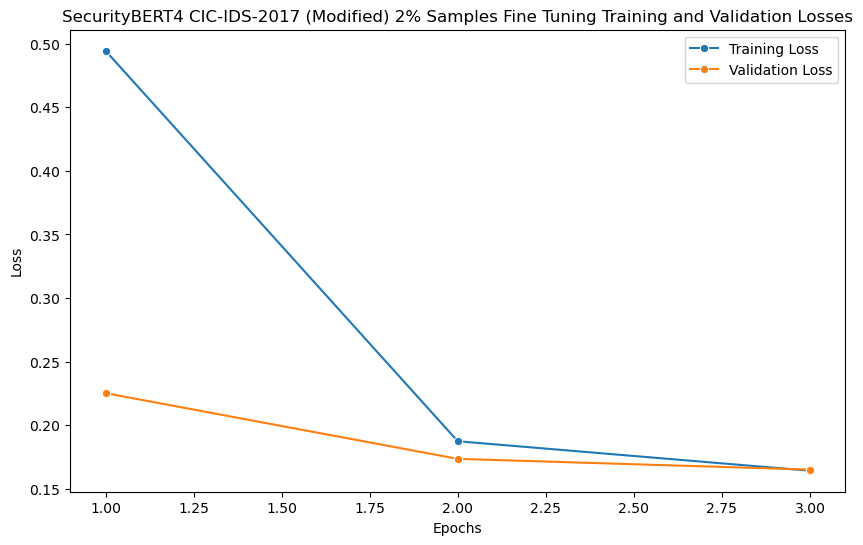

In [88]:

epochs = range(1, EPOCHS+1)
train_losses = history['train_loss']
val_losses = history['val_loss']

# Création du graphique
plt.figure(figsize=(10, 6))

# Tracé des courbes de training et de validation losses
sns.lineplot(x=epochs, y=train_losses, label='Training Loss',marker="o")
sns.lineplot(x=epochs, y=val_losses, label='Validation Loss',marker="o")

# Ajout de titres et de légendes
plt.title(f'{figure_version} Training and Validation Losses')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.savefig(f'./{figure_file_name}-{num_epochs}ep-training-validation-losses.png',dpi=780)
# Affichage du graphique
plt.show()


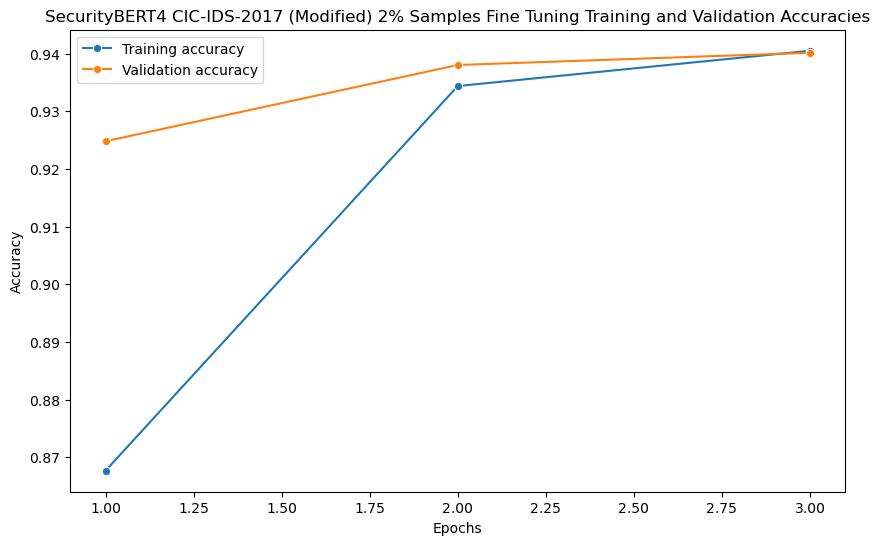

In [89]:
epochs = range(1, EPOCHS+1)
train_accuracies = [tens.item() for tens in history['train_acc']]
val_accuracies = [tens.item() for tens in history['val_acc']]

# Création du graphique
plt.figure(figsize=(10, 6))

# Tracé des courbes de training et de validation losses
sns.lineplot(x=epochs, y=train_accuracies, label='Training accuracy',marker='o')
sns.lineplot(x=epochs, y=val_accuracies, label='Validation accuracy',marker='o')

# Ajout de titres et de légendes
plt.title(f'{figure_version} Training and Validation Accuracies')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.savefig(f'./{figure_file_name}-{num_epochs}ep-training-validation-accuracies.png',dpi=780)
# Affichage du graphique
plt.show()


In [90]:
y_pred,y_proba,real_values = get_predictions(securityBert,test_loader)

Predictions: 100%|██████████| 4192/4192 [04:02<00:00, 17.28it/s]


In [91]:
torch.save(y_pred,f"./{model_directory}y_pred_{model_version}.pt")
torch.save(y_proba,f"./{model_directory}y_proba_{model_version}.pt")
torch.save(real_values,f"./{model_directory}real_values_{model_version}.pt")

In [92]:
from sklearn.metrics import confusion_matrix,classification_report

In [93]:
target_names = ['Backdoor', 'DDoS_HTTP', 'DDoS_ICMP', 'DDoS_TCP', 'DDoS_UDP',
       'Fingerprinting', 'MITM', 'Normal', 'Password', 'Port_Scanning',
       'Ransomware', 'SQL_injection', 'Uploading', 'Vulnerability_scanner',
       'XSS']

In [94]:
s = set()

In [95]:
for elt in y_pred:
  s.add(elt.item())

In [96]:
actual_considered_classes = [TARGET_LIST[i] for i in s]
actual_considered_classes

['Benign',
 'Botnet',
 'Bruteforce-FTP',
 'Bruteforce-SSH',
 'DDoS',
 'DDoS-DNS',
 'DDoS-Ddossim',
 'DDoS-HOIC',
 'DDoS-LDAP',
 'DDoS-LOIC-HTTP',
 'DDoS-MSSQL',
 'DDoS-NTP',
 'DDoS-NetBIOS',
 'DDoS-SNMP',
 'DDoS-Slowloris',
 'DDoS-Syn',
 'DDoS-TFTP',
 'DDoS-UDP',
 'DDoS-UDPLag',
 'DoS-Goldeneye',
 'DoS-Hulk',
 'DoS-Rudy',
 'DoS-Slowbody',
 'DoS-Slowheaders',
 'DoS-Slowhttptest',
 'DoS-Slowloris',
 'DoS-Slowread',
 'Infiltration',
 'Portscan',
 'Webattack-bruteforce']

In [97]:
data[label_col].value_counts()

Label
Benign                  195001
DDoS-LOIC-HTTP           62784
DoS-Hulk                 57652
DDoS-HOIC                55254
Botnet                   54196
DDoS                     53838
DDoS-NTP                 53704
DDoS-TFTP                53254
Bruteforce-SSH           53222
Infiltration             53174
DoS-Goldeneye            52324
DDoS-Syn                 47757
DDoS-UDP                 28863
DoS-Slowloris            15243
DDoS-MSSQL               11784
DDoS-UDPLag               8452
Bruteforce-FTP            5984
DoS-Slowhttptest          5271
DDoS-Ddossim              5115
DDoS-DNS                  3668
DoS-Slowread              2786
Portscan                  2255
DDoS-LDAP                 2092
Webattack-bruteforce      2020
DDoS-SNMP                 2017
DDoS-Slowloris            1858
DoS-Slowheaders           1649
Webattack-XSS              876
DoS-Rudy                   699
DDoS-NetBIOS               675
DoS-Slowbody               621
Webattack-SQLi              99
Do

In [98]:
def show_confusion_matrix(confusion_matrix, annot):

    plt.figure(figsize=(20, 12))
    sns.heatmap(confusion_matrix, annot=annot, cmap='Blues', fmt='')
    plt.xticks(rotation=90)
    plt.title(f"{figure_version} {num_epochs} Epochs Confusion Matrix")
    plt.ylabel('Real threats')
    plt.xlabel('Predicted threats')
    plt.savefig(f'./{figure_file_name}-{num_epochs}ep-confusion-matrix.png',bbox_inches="tight",dpi=780)
    plt.show()

In [99]:
from sklearn.metrics import confusion_matrix,classification_report

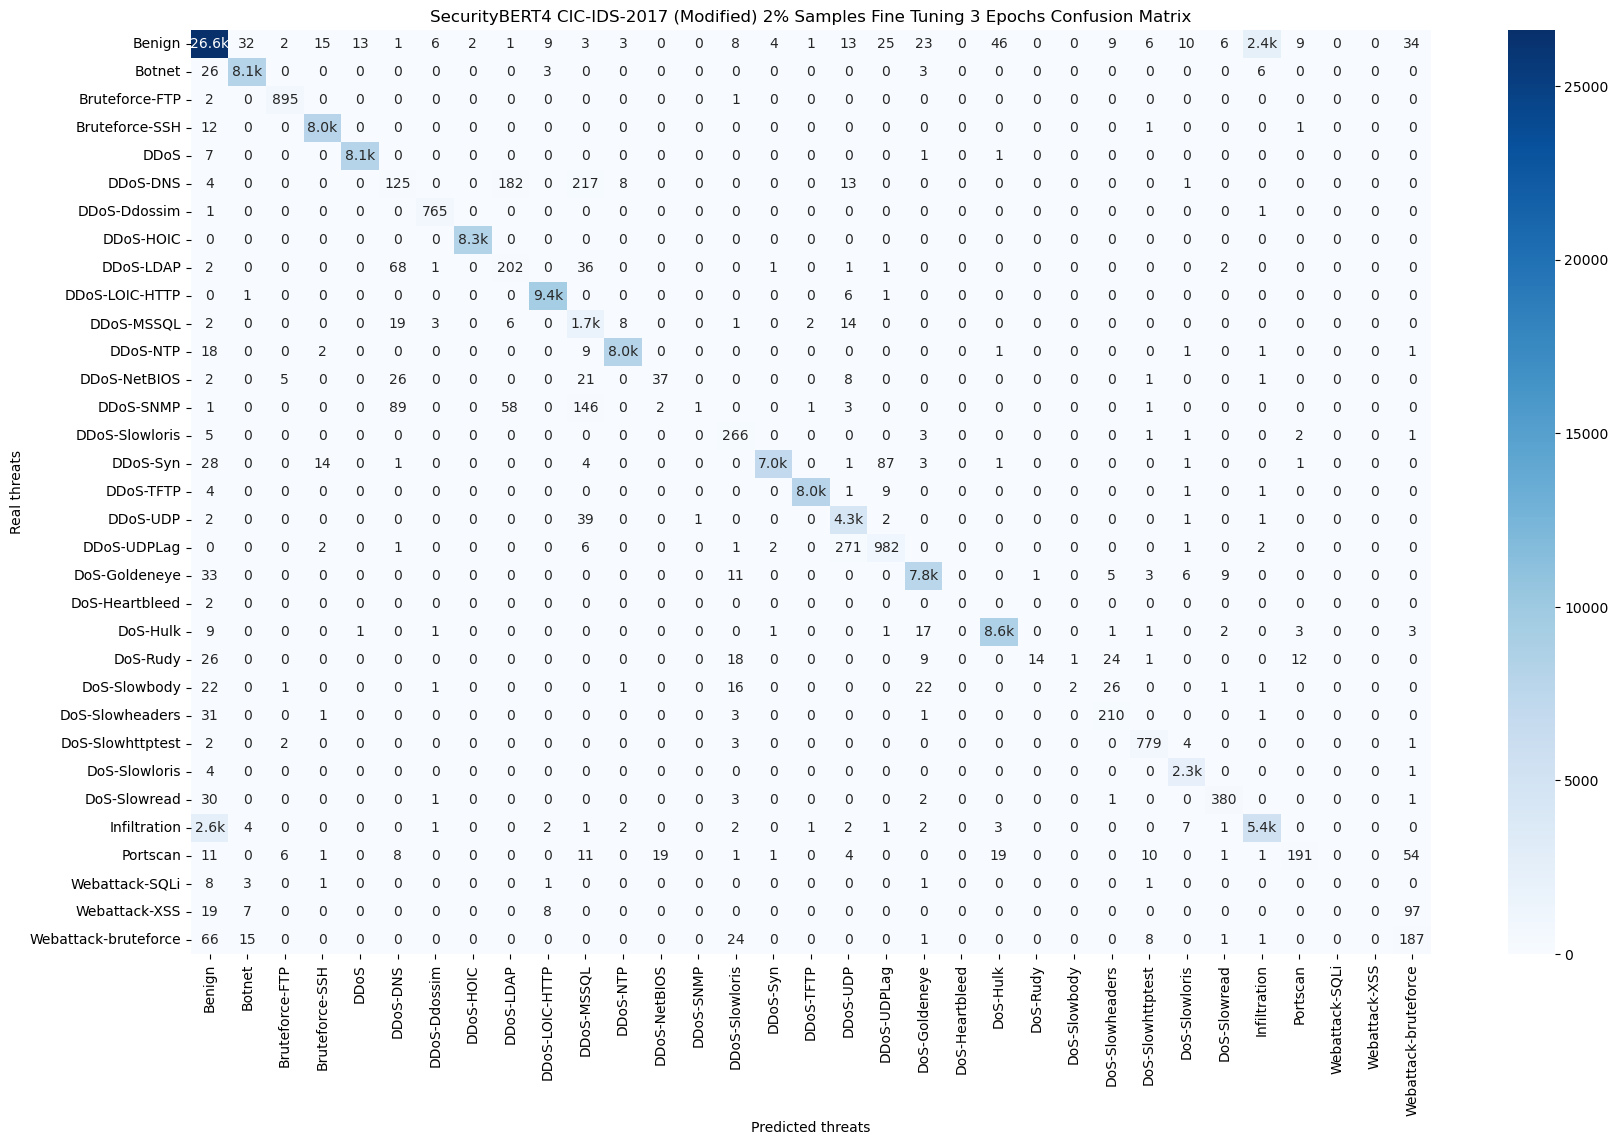

In [100]:
cm = confusion_matrix(real_values,y_pred)

def format_k(x):
    return f"{x/1000:.1f}k" if x >= 1000 else str(x)

# Create formatted annotations
annot = np.array([[format_k(val) for val in row] for row in cm])
df_cm = pd.DataFrame(cm,index=TARGET_LIST,columns=TARGET_LIST)
show_confusion_matrix(df_cm, annot)

In [101]:
print(classification_report(real_values,y_pred,target_names=TARGET_LIST))

                      precision    recall  f1-score   support

              Benign       0.90      0.91      0.90     29250
              Botnet       0.99      1.00      0.99      8129
      Bruteforce-FTP       0.98      1.00      0.99       898
      Bruteforce-SSH       1.00      1.00      1.00      7983
                DDoS       1.00      1.00      1.00      8076
            DDoS-DNS       0.37      0.23      0.28       550
        DDoS-Ddossim       0.98      1.00      0.99       767
           DDoS-HOIC       1.00      1.00      1.00      8288
           DDoS-LDAP       0.45      0.64      0.53       314
      DDoS-LOIC-HTTP       1.00      1.00      1.00      9418
          DDoS-MSSQL       0.78      0.97      0.86      1768
            DDoS-NTP       1.00      1.00      1.00      8056
        DDoS-NetBIOS       0.64      0.37      0.47       101
           DDoS-SNMP       0.50      0.00      0.01       302
      DDoS-Slowloris       0.74      0.95      0.84       279
       

In [102]:
s = set()
for elt in y_pred:
    s.add(elt.item())
actual_considered_classes = [le.classes_[i] for i in s]
print(actual_considered_classes)

counts = test_set['target'].value_counts().sort_index()
class_names = le.inverse_transform(counts.index)
class_counts = pd.Series(counts.values, index=class_names)
class_counts = class_counts.sort_values(ascending=False)  # or .sort_index()
print(class_counts)

['Benign', 'Botnet', 'Bruteforce-FTP', 'Bruteforce-SSH', 'DDoS', 'DDoS-DNS', 'DDoS-Ddossim', 'DDoS-HOIC', 'DDoS-LDAP', 'DDoS-LOIC-HTTP', 'DDoS-MSSQL', 'DDoS-NTP', 'DDoS-NetBIOS', 'DDoS-SNMP', 'DDoS-Slowloris', 'DDoS-Syn', 'DDoS-TFTP', 'DDoS-UDP', 'DDoS-UDPLag', 'DoS-Goldeneye', 'DoS-Hulk', 'DoS-Rudy', 'DoS-Slowbody', 'DoS-Slowheaders', 'DoS-Slowhttptest', 'DoS-Slowloris', 'DoS-Slowread', 'Infiltration', 'Portscan', 'Webattack-bruteforce']
Benign                  29250
DDoS-LOIC-HTTP           9418
DoS-Hulk                 8648
DDoS-HOIC                8288
Botnet                   8129
DDoS                     8076
DDoS-NTP                 8056
DDoS-TFTP                7988
Bruteforce-SSH           7983
Infiltration             7976
DoS-Goldeneye            7849
DDoS-Syn                 7164
DDoS-UDP                 4329
DoS-Slowloris            2286
DDoS-MSSQL               1768
DDoS-UDPLag              1268
Bruteforce-FTP            898
DoS-Slowhttptest          791
DDoS-Ddossim     

In [103]:
y_true = real_values.cpu().numpy()
y_score = y_pred.cpu().numpy()

In [104]:
import matplotlib.pyplot as plt

def plot_test_metrics_table(test_metrics, figure_version, num_epochs, figure_file_name):
    """
    Plots and saves a table of test metrics as a figure.

    Parameters:
    - test_metrics: defaultdict or dict with scalar values
    - figure_version: str (e.g., 'v1.0')
    - num_epochs: int
    - figure_file_name: str (e.g., 'tab-transformer')
    """

    # Define a mapping from metric keys to display names
    metric_name_map = {
        "micro_acc": "Overall Accuracy",
        "micro_rec": "Overall Recall",
        "micro_prec": "Overall Precision",
        "micro_f1": "Overall F1 Score",
        "micro_roc_auc": "Overall ROC AUC",
        "macro_acc": "Class-Averaged Accuracy",
        "macro_rec": "Class-Averaged Recall",
        "macro_prec": "Class-Averaged Precision",
        "macro_f1": "Class-Averaged F1 Score",
        "macro_roc_auc": "Class-Averaged ROC AUC",
        # Add more mappings as needed
    }

    # Convert metrics to a list of [metric_name, value] rows
    data = []
    for key, value in test_metrics.items():
        label = metric_name_map.get(key, key)  # Use key as fallback if not in map
        data.append([label, f"{value:.4f}"])

    fig, ax = plt.subplots(figsize=(8, len(data) * 0.4 + 1))
    ax.axis('off')

    table = ax.table(
        cellText=data,
        colLabels=["Metric", "Score"],
        loc='center',
        cellLoc='center'
    )
    table.auto_set_font_size(False)
    table.set_fontsize(12)
    table.scale(1, 1.5)

    plt.title(f"{figure_version} {num_epochs} Epochs Test Scores", fontsize=14, pad=20)

    output_path = f"./{figure_file_name}-{num_epochs}ep-test-scores.png"
    plt.savefig(output_path, dpi=300, bbox_inches='tight')
    plt.show()


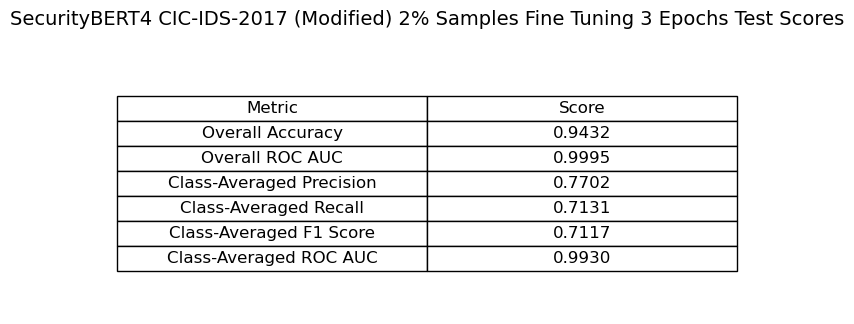

In [105]:
from collections import defaultdict
from sklearn.preprocessing import label_binarize
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
)
import numpy as np
import torch
from sklearn.metrics import balanced_accuracy_score

# Assume these are already defined:
# y_true: true class labels (1D array-like)
# y_pred: predicted class labels (1D array-like)
# y_proba: predicted probabilities (2D array-like: [n_samples, n_classes])

n_classes = len(np.unique(y_true))
y_true_bin = label_binarize(y_true, classes=np.arange(n_classes))

test_metrics = defaultdict(float)  # ⬅️ Each key holds a single float value

# Micro metrics
test_metrics["micro_acc"] = accuracy_score(y_true, y_pred)
try:
    test_metrics["micro_roc_auc"] = roc_auc_score(
        y_true_bin, y_proba, average="micro", multi_class="ovr"
    )
except ValueError:
    test_metrics["micro_roc_auc"] = float("nan")

test_metrics["macro_prec"] = precision_score(y_true, y_pred, average="macro", zero_division=0)
test_metrics["macro_rec"] = recall_score(y_true, y_pred, average="macro", zero_division=0)
test_metrics["macro_f1"] = f1_score(y_true, y_pred, average="macro")

# ROC AUC Scores
try:
    test_metrics["macro_roc_auc"] = roc_auc_score(
        y_true_bin, y_proba, average="macro", multi_class="ovr"
    )
except ValueError:
    test_metrics["macro_roc_auc"] = float("nan")

# Save metrics
torch.save(dict(test_metrics), f"./{model_directory}test_metrics_{model_version}.pt")

# Plot
plot_test_metrics_table(test_metrics, figure_version=figure_version, num_epochs=num_epochs, figure_file_name=figure_file_name)